In [5]:
from pathlib import Path
import numpy as np
import torch
import glob
import matplotlib.pyplot as plt
import importlib.util
from src.tem import world
from tem import analyse, plot

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Choose which trained model to load
run_dir = Path('/Users/nmorton/PycharmProjects/Summaries/2025-02-21/run1')
index = '19999'

In [6]:
# Load the model: use import library to import module from specified path
model_spec = importlib.util.spec_from_file_location("model", run_dir / 'script' / 'model.py')
model = importlib.util.module_from_spec(model_spec)
model_spec.loader.exec_module(model)

In [10]:
# Load the parameters of the model
params = torch.load(run_dir / 'model' / f'params_{index}.pt', weights_only=False)
# Create a new tem model with the loaded parameters
tem = model.Model(params)
# Load the model weights after training
model_weights = torch.load(run_dir / 'model' / f'tem_{index}.pt')
# Set the model weights to the loaded trained model weights
tem.load_state_dict(model_weights)
# Make sure model is in evaluate mode (not crucial because it doesn't currently use dropout or batchnorm layers)
tem.eval()

Model(
  (alpha): ParameterList(
      (0): Parameter containing: [torch.float32 of size ]
      (1): Parameter containing: [torch.float32 of size ]
      (2): Parameter containing: [torch.float32 of size ]
      (3): Parameter containing: [torch.float32 of size ]
      (4): Parameter containing: [torch.float32 of size ]
  )
  (w_p): ParameterList(
      (0): Parameter containing: [torch.float32 of size ]
      (1): Parameter containing: [torch.float32 of size ]
      (2): Parameter containing: [torch.float32 of size ]
      (3): Parameter containing: [torch.float32 of size ]
      (4): Parameter containing: [torch.float32 of size ]
  )
  (g_init): ParameterList(
      (0): Parameter containing: [torch.float32 of size 30]
      (1): Parameter containing: [torch.float32 of size 30]
      (2): Parameter containing: [torch.float32 of size 24]
      (3): Parameter containing: [torch.float32 of size 18]
      (4): Parameter containing: [torch.float32 of size 18]
  )
  (logsig_g_init): Param

In [16]:
# Make list of all the environments that this model was trained on
envs = list(glob.iglob(str(run_dir / 'script' / 'envs' / '*.json')))
# Set which environments will include shiny objects
shiny_envs = [False, False, True, True]
# Set the number of walks to execute in parallel (batch size)
n_walks = len(shiny_envs)
# Select environments from the environments included in training
environments = [world.World(graph, randomise_observations=True, shiny=(params['shiny'] if shiny_envs[env_i] else None))
                for env_i, graph in enumerate(np.random.choice(envs, n_walks))]
# Determine the length of each walk
walk_len = np.median([env.n_locations * 50 for env in environments]).astype(int)
# And generate walks for each environment
walks = [env.generate_walks(walk_len, 1)[0] for env in environments]

In [32]:
# Generate model input from specified walk and environment: group steps from all environments together to feed to model in parallel
model_input = [[[[walks[i][j][k]][0] for i in range(len(walks))] for k in range(3)] for j in range(walk_len)]
for i_step, step in enumerate(model_input):
    model_input[i_step][1] = torch.stack(step[1], dim=0)

# Run a forward pass through the model using this data, without accumulating gradients
with torch.no_grad():
    forward = tem(model_input, prev_iter=None)

In [34]:
# Decide whether to include stay-still actions as valid occasions for inference
include_stay_still = True

# Compare trained model performance to a node agent and an edge agent
correct_model, correct_node, correct_edge = analyse.compare_to_agents(forward, tem, environments, include_stay_still=include_stay_still)

# Analyse occurrences of zero-shot inference: predict the right observation arriving from a visited node with a new action
zero_shot = analyse.zero_shot(forward, tem, environments, include_stay_still=include_stay_still)

# Generate occupancy maps: how much time TEM spends at every location
occupation = analyse.location_occupation(forward, tem, environments)

In [40]:
# Generate rate maps
g, p = analyse.rate_map(forward, tem, environments)

# Calculate accuracy leaving from and arriving to each location
from_acc, to_acc = analyse.location_accuracy(forward, tem, environments)

# Choose which environment to plot
env_to_plot = 0
# And when averaging environments, e.g. for calculating average accuracy, decide which environments to include
envs_to_avg = shiny_envs if shiny_envs[env_to_plot] else [not shiny_env for shiny_env in shiny_envs]

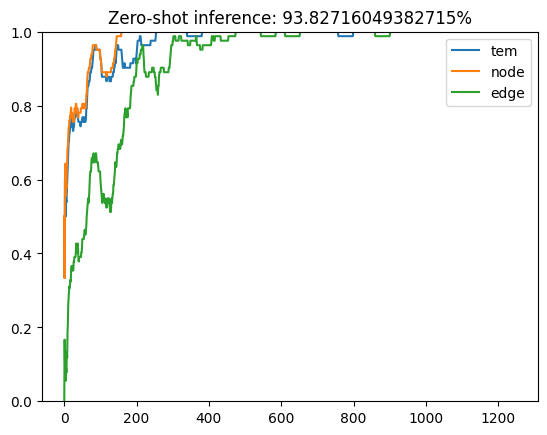

In [45]:
# Plot results of agent comparison and zero-shot inference analysis
filt_size = 41
plt.figure()
plt.plot(
    analyse.smooth(np.mean(np.array([env for env_i, env in enumerate(correct_model) if envs_to_avg[env_i]]), 0)[1:], filt_size), label='tem')
plt.plot(analyse.smooth(np.mean(np.array([env for env_i, env in enumerate(correct_node) if envs_to_avg[env_i]]), 0)[1:], filt_size), label='node')
plt.plot(analyse.smooth(np.mean(np.array([env for env_i, env in enumerate(correct_edge) if envs_to_avg[env_i]]), 0)[1:], filt_size), label='edge')
plt.ylim(0, 1)
plt.legend()
plt.title('Zero-shot inference: ' + str(np.mean([np.mean(env) for env_i, env in enumerate(zero_shot) if envs_to_avg[env_i]]) * 100) + '%')
plt.show()

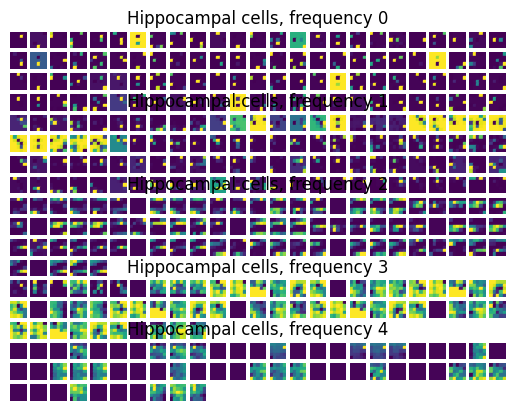

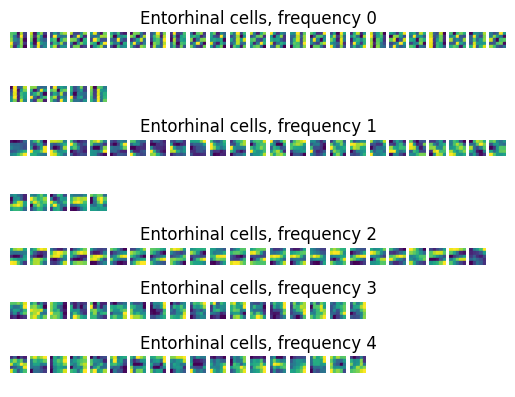

In [46]:
# Plot rate maps for all cells
plot.plot_cells(p[env_to_plot], g[env_to_plot], environments[env_to_plot], n_f_ovc=(params['n_f_ovc'] if 'n_f_ovc' in params else 0), columns = 25)

Text(0.5, 1.0, 'Accuracy from location')

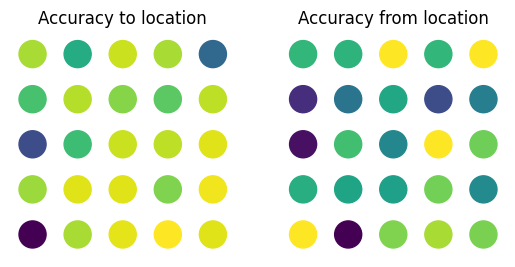

In [47]:
# Plot accuracy separated by location
plt.figure()
ax = plt.subplot(1,2,1)
plot.plot_map(environments[env_to_plot], np.array(to_acc[env_to_plot]), ax)
ax.set_title('Accuracy to location')
ax = plt.subplot(1,2,2)
plot.plot_map(environments[env_to_plot], np.array(from_acc[env_to_plot]), ax)
ax.set_title('Accuracy from location')

Text(0.5, 1.0, 'Walk and average occupation')

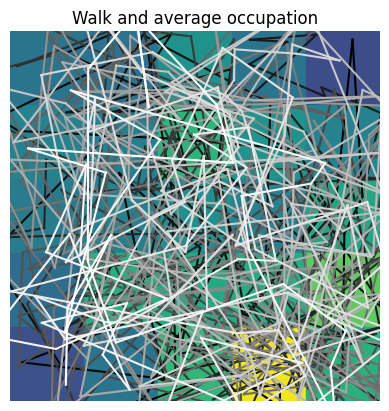

In [48]:
# Plot occupation per location, then add walks on top
ax = plot.plot_map(environments[env_to_plot], np.array(occupation[env_to_plot]) / sum(occupation[env_to_plot]) * environments[env_to_plot].n_locations,
                   min_val=0, max_val=2, ax=None, shape='square', radius=1/np.sqrt(environments[env_to_plot].n_locations))
ax = plot.plot_walk(environments[env_to_plot], walks[env_to_plot], ax=ax, n_steps=max(1, int(len(walks[env_to_plot]) / 500)))
plt.title('Walk and average occupation')